# Vein Phase 3 — BiomedParse Fine-Tuning

Exact copy of Phase 2 approach. Starts from the Phase 2 vein checkpoint and adds ~40k new vein examples from `veins_vlm_finetuning` to the existing `Fascia_Detection` combined dataset.

| | Phase 2 | Phase 3 (this) |
|---|---|---|
| Start weights | Phase 1 fascia ckpt | Phase 2 vein ckpt |
| Dataset | Fascia_Detection (2364 fascia + 1731 vein) | Same + 40k new vein |
| Fascia caption | `fascia layer in PeripheralVascular Ultrasound` | same (kept for contrastive signal) |
| Vein caption | `vein in PeripheralVascular Ultrasound` | same |
| LR | 5e-5 | 5e-5 |
| Batch | 16 | 16 |
| FP16 | True | True |
| Epochs | 10 (early stop) | 1 |

## 0 · Imports & Paths

In [56]:
import os
import sys
import json
import random
import shutil
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

BASE_DIR     = Path(r"C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection")
BIOMEDPARSE  = BASE_DIR / "BiomedParse"
FASCIA_DATA  = BIOMEDPARSE / "biomedparse_datasets" / "Fascia_Detection"
VEIN_DATA    = BASE_DIR / "veins_vlm_finetuning"
DATASET_ROOT = BIOMEDPARSE / "biomedparse_datasets" / "Fascia_Vein_Detection_v3"

# Phase 2 vein checkpoint — last model trained on vein data (0.728 IoU)
VEIN_CKPT = (
    BIOMEDPARSE / "output" / "fascia_vein_finetuning"
    / "biomed_fascia_finetuning.yaml_conf~" / "run_1"
    / "00001785" / "default" / "model_state_dict.pt"
)

DATASET_NAME      = "Fascia_Vein_Detection_v3"
TRAIN_DATASET     = f"biomed_{DATASET_NAME}_train"
TEST_DATASET      = f"biomed_{DATASET_NAME}_test"
FASCIA_CAT_ID     = 17
VEIN_CAT_ID       = 18
FASCIA_PROMPT     = 'fascia layer in PeripheralVascular Ultrasound'
VEIN_PROMPT       = 'vein in PeripheralVascular Ultrasound'
RANDOM_SEED       = 42
TEST_FRACTION     = 0.10
VIEW_PREFIX       = {'transverse': 'trans', 'longitudinal': 'long'}

print("VEIN_CKPT exists:", VEIN_CKPT.exists())
print("FASCIA_DATA  :", FASCIA_DATA.exists())
print("VEIN_DATA    :", VEIN_DATA.exists())

VEIN_CKPT exists: True
FASCIA_DATA  : True
VEIN_DATA    : True


## 1 · Inspect source datasets

In [57]:
# Existing Fascia_Detection
fd_train = json.loads((FASCIA_DATA / 'train.json').read_text(encoding='utf-8'))
fd_test  = json.loads((FASCIA_DATA / 'test.json').read_text(encoding='utf-8'))
fd_fascia_train = [a for a in fd_train['annotations'] if a['category_id'] == FASCIA_CAT_ID]
fd_vein_train   = [a for a in fd_train['annotations'] if a['category_id'] == VEIN_CAT_ID]
fd_fascia_test  = [a for a in fd_test['annotations']  if a['category_id'] == FASCIA_CAT_ID]
fd_vein_test    = [a for a in fd_test['annotations']  if a['category_id'] == VEIN_CAT_ID]
print(f"Fascia_Detection train: {len(fd_fascia_train)} fascia + {len(fd_vein_train)} vein")
print(f"Fascia_Detection test : {len(fd_fascia_test)} fascia + {len(fd_vein_test)} vein")

# New vein data
views = {
    'transverse':   VEIN_DATA / 'transverse_view',
    'longitudinal': VEIN_DATA / 'longitudinal_view',
}
for vname, vdir in views.items():
    frames = list((vdir / 'frames').glob('*.jpg'))
    masks  = list((vdir / 'masks').glob('*.png'))
    print(f"new vein {vname:14s}: {len(frames)} frames, {len(masks)} masks")

Fascia_Detection train: 2364 fascia + 1731 vein
Fascia_Detection test : 415 fascia + 305 vein
new vein transverse    : 31938 frames, 40959 masks
new vein longitudinal  : 2789 frames, 2834 masks


## 2 · Collect new vein triplets

In [58]:
random.seed(RANDOM_SEED)

# Collect (frame_path, mask_path, view_name) from veins_vlm_finetuning
new_triplets = []
for view_name, view_dir in views.items():
    frames_dir   = view_dir / 'frames'
    masks_dir    = view_dir / 'masks'
    frame_lookup = {fp.stem: fp for fp in frames_dir.glob('*.jpg')}
    for mp in masks_dir.glob('*.png'):
        idx = mp.stem.rfind('_cls')
        if idx == -1:
            continue
        frame_base = mp.stem[:idx]
        if frame_base in frame_lookup:
            new_triplets.append((frame_lookup[frame_base], mp, view_name))

random.shuffle(new_triplets)
n_test_new        = max(1, int(len(new_triplets) * TEST_FRACTION))
new_train_triplets = new_triplets[:-n_test_new]
new_test_triplets  = new_triplets[-n_test_new:]
print(f"New vein triplets — train: {len(new_train_triplets)}  test: {len(new_test_triplets)}")

New vein triplets — train: 39414  test: 4379


## 3 · Build combined dataset directory (hardlinks)

In [59]:
for sub in ['train', 'train_mask', 'test', 'test_mask']:
    p = DATASET_ROOT / sub
    if p.exists():
        shutil.rmtree(p)
    p.mkdir(parents=True)

def safe_link(src, dst):
    if dst.exists():
        return
    try:
        os.link(src, dst)
    except OSError:
        shutil.copy2(src, dst)

# --- Copy existing Fascia_Detection files ---
for split in ['train', 'test']:
    src_img  = FASCIA_DATA / split
    src_mask = FASCIA_DATA / f"{split}_mask"
    dst_img  = DATASET_ROOT / split
    dst_mask = DATASET_ROOT / f"{split}_mask"
    anns = fd_train['annotations'] if split == 'train' else fd_test['annotations']
    for a in tqdm(anns, desc=f'Fascia_Detection {split}'):
        safe_link(src_img  / a['file_name'], dst_img  / a['file_name'])
        safe_link(src_mask / a['mask_file'], dst_mask / a['mask_file'])

# --- Hardlink new vein files ---
def populate_new(triplets, split):
    img_dir  = DATASET_ROOT / split
    mask_dir = DATASET_ROOT / f"{split}_mask"
    entries  = []
    for fp, mp, view_name in tqdm(triplets, desc=f'new vein {split}'):
        prefix        = VIEW_PREFIX[view_name]
        dst_img_name  = f"{prefix}_{fp.name}"
        dst_mask_name = f"{prefix}_{mp.name}"
        safe_link(fp, img_dir  / dst_img_name)
        safe_link(mp, mask_dir / dst_mask_name)
        entries.append({'img': dst_img_name, 'mask': dst_mask_name})
    return entries

new_train_entries = populate_new(new_train_triplets, 'train')
new_test_entries  = populate_new(new_test_triplets,  'test')

print(f"train: {len(list((DATASET_ROOT/'train').iterdir()))} imgs, {len(list((DATASET_ROOT/'train_mask').iterdir()))} masks")
print(f"test : {len(list((DATASET_ROOT/'test').iterdir()))} imgs, {len(list((DATASET_ROOT/'test_mask').iterdir()))} masks")

Fascia_Detection train:   0%|          | 0/4095 [00:00<?, ?it/s]

Fascia_Detection test:   0%|          | 0/720 [00:00<?, ?it/s]

new vein train:   0%|          | 0/39414 [00:00<?, ?it/s]

new vein test:   0%|          | 0/4379 [00:00<?, ?it/s]

train: 36122 imgs, 43509 masks
test : 5012 imgs, 5099 masks


## 4 · Build combined COCO JSON

In [60]:
CATEGORIES = [
    {'id': FASCIA_CAT_ID, 'name': 'fascia layer', 'supercategory': 'anatomy'},
    {'id': VEIN_CAT_ID,   'name': 'vein',          'supercategory': 'vessel'},
]

def build_combined_json(fd_data, new_entries, split):
    img_dir    = DATASET_ROOT / split
    images     = []
    annotations = []
    img_name_to_id = {}
    ann_id = sent_id = 0

    def add_annotation(img_name, mask_name, cat_id, prompt):
        nonlocal ann_id, sent_id
        if img_name not in img_name_to_id:
            iid = len(img_name_to_id)
            img_name_to_id[img_name] = iid
            try:
                with Image.open(img_dir / img_name) as im:
                    w, h = im.size
            except Exception:
                w, h = 512, 512
            images.append({'id': iid, 'file_name': img_name, 'height': h, 'width': w})
        iid = img_name_to_id[img_name]
        annotations.append({
            'id': ann_id, 'ann_id': ann_id, 'ref_id': ann_id,
            'image_id': iid, 'category_id': cat_id,
            'file_name': img_name, 'mask_file': mask_name,
            'split': split, 'iscrowd': 0,
            'sentences': [{'raw': prompt, 'sent': prompt, 'sent_id': sent_id}],
            'sent_ids': [sent_id],
        })
        ann_id  += 1
        sent_id += 1

    # Existing Fascia_Detection annotations
    for a in tqdm(fd_data['annotations'], desc=f'FD anns {split}'):
        cat_id = a['category_id']
        prompt = FASCIA_PROMPT if cat_id == FASCIA_CAT_ID else VEIN_PROMPT
        add_annotation(a['file_name'], a['mask_file'], cat_id, prompt)

    # New vein annotations
    for e in tqdm(new_entries, desc=f'new vein anns {split}'):
        add_annotation(e['img'], e['mask'], VEIN_CAT_ID, VEIN_PROMPT)

    coco = {
        'info': {}, 'licenses': [],
        'images': images,
        'categories': CATEGORIES,
        'annotations': annotations,
    }
    out = DATASET_ROOT / f"{split}.json"
    with open(out, 'w') as f:
        json.dump(coco, f)

    fascia_n = sum(1 for a in annotations if a['category_id'] == FASCIA_CAT_ID)
    vein_n   = sum(1 for a in annotations if a['category_id'] == VEIN_CAT_ID)
    print(f"  {split}.json: {len(images)} images | {fascia_n} fascia + {vein_n} vein = {len(annotations)} total")
    return coco

train_coco = build_combined_json(fd_train, new_train_entries, 'train')
test_coco  = build_combined_json(fd_test,  new_test_entries,  'test')

# Sanity check
a0 = train_coco['annotations'][0]
print(f"\nFirst ann: cat={a0['category_id']} caption='{a0['sentences'][0]['sent']}'")
print(f"Image exists: {(DATASET_ROOT/'train'/a0['file_name']).exists()}")
print(f"Mask  exists: {(DATASET_ROOT/'train_mask'/a0['mask_file']).exists()}")

FD anns train:   0%|          | 0/4095 [00:00<?, ?it/s]

new vein anns train:   0%|          | 0/39414 [00:00<?, ?it/s]

  train.json: 36122 images | 2364 fascia + 41145 vein = 43509 total


FD anns test:   0%|          | 0/720 [00:00<?, ?it/s]

new vein anns test:   0%|          | 0/4379 [00:00<?, ?it/s]

  test.json: 5012 images | 415 fascia + 4684 vein = 5099 total

First ann: cat=17 caption='fascia layer in PeripheralVascular Ultrasound'
Image exists: True
Mask  exists: True


## 5 · Register dataset

In [61]:
reg_path = BIOMEDPARSE / 'datasets' / 'registration' / 'register_biomed_datasets.py'
content  = reg_path.read_text(encoding='utf-8')

NEW_BLOCK = """
# Fascia+Vein v3 — Fascia_Detection + 40k new vein examples
for name in ['Fascia_Vein_Detection_v3']:
    for split in ['train', 'test']:
        dataname = f'biomed_{name}_{split}'
        _PREDEFINED_SPLITS_BIOMED[dataname] = (f"{name}/{split}", f"{name}/{split}.json")
# biomed_Fascia_Vein_Detection_v3_train, biomed_Fascia_Vein_Detection_v3_test
"""

if 'Fascia_Vein_Detection_v3' in content:
    print("Already registered.")
else:
    insert_at = content.find('def get_metadata():')
    if insert_at == -1:
        raise ValueError("Cannot find insertion point")
    reg_path.write_text(content[:insert_at] + NEW_BLOCK + '\n\n' + content[insert_at:], encoding='utf-8')
    print("Registered Fascia_Vein_Detection_v3.")

assert 'Fascia_Vein_Detection_v3' in reg_path.read_text(encoding='utf-8')
print("Verified.")

Registered Fascia_Vein_Detection_v3.
Verified.


## 6 · Train — 1 epoch, save to D:

In [62]:
import re
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU — aborting.")

assert VEIN_CKPT.exists(), f"Phase 2 checkpoint not found: {VEIN_CKPT}"
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"Ckpt: {VEIN_CKPT}")

# Patch YAML to point to Fascia_Vein_Detection_v3
import re as _re
yaml_path = BIOMEDPARSE / 'configs' / 'biomed_fascia_finetuning.yaml'
yaml_text = yaml_path.read_text(encoding='utf-8')
yaml_text = _re.sub(r"(DATASETS:\s*\n\s*TRAIN:\s*)\[.*?\]", rf"\1['{TRAIN_DATASET}']", yaml_text)
yaml_text = _re.sub(r"(  TEST:\s*)\[.*?\]",                 rf"\1['{TEST_DATASET}']",  yaml_text)
yaml_path.write_text(yaml_text, encoding='utf-8')
print(f"YAML patched -> TRAIN={TRAIN_DATASET}")

# Save to D: (360 GB free)
SAVE_DIR = r"D:\vein_phase3"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Checkpoints -> {SAVE_DIR}")

env = dict(os.environ)
env['DETECTRON2_DATASETS'] = str(BIOMEDPARSE / 'biomedparse_datasets') + os.sep
env['DATASET']             = str(BIOMEDPARSE / 'biomedparse_datasets') + os.sep
env['DATASET2']            = str(BIOMEDPARSE / 'biomedparse_datasets') + os.sep
env['VLDATASET']           = str(BIOMEDPARSE / 'biomedparse_datasets') + os.sep
env['PYTHONPATH'] = (
    str(BASE_DIR / 'stubs') + os.pathsep +
    str(BIOMEDPARSE)        + os.pathsep +
    env.get('PYTHONPATH', '')
)
env['PYTHONUTF8']              = '1'
env['PYTHONUNBUFFERED']        = '1'
env['CUDA_VISIBLE_DEVICES']    = '0'
env['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

cmd = [
    sys.executable, '-u', 'entry.py', 'train',
    '--conf_files', 'configs/biomed_fascia_finetuning.yaml',
    '--overrides',
    'FP16',                          'True',
    'RANDOM_SEED',                   '2024',
    'BioMed.INPUT.IMAGE_SIZE',       '512',
    'TRAIN.BATCH_SIZE_TOTAL',        '16',
    'TRAIN.BATCH_SIZE_PER_GPU',      '16',
    'TEST.BATCH_SIZE_TOTAL',         '1',
    'SOLVER.MAX_NUM_EPOCHS',         '1',
    'SOLVER.BASE_LR',                '0.00005',
    'SOLVER.FIX_PARAM.backbone',     'True',
    'SOLVER.FIX_PARAM.lang_encoder', 'True',
    'SOLVER.FIX_PARAM.pixel_decoder','False',
    'DATALOADER.NUM_WORKERS',        '0',
    'LOG_EVERY',                     '50',
    'WEIGHT',                        'True',
    'RESUME_FROM',                   str(VEIN_CKPT),
    'SAVE_DIR',                      SAVE_DIR,
]

n_train = len(train_coco['annotations'])
fascia_n = sum(1 for a in train_coco['annotations'] if a['category_id'] == FASCIA_CAT_ID)
vein_n   = sum(1 for a in train_coco['annotations'] if a['category_id'] == VEIN_CAT_ID)
print('=' * 65)
print(f'Phase 3 | start=Phase2 vein ckpt | 1 epoch | LR=5e-5 | batch=16')
print(f'Dataset: {n_train} total ({fascia_n} fascia + {vein_n} vein)')
print('=' * 65)

proc = subprocess.Popen(
    cmd,
    cwd=str(BIOMEDPARSE),
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding='utf-8',
    errors='replace',
)

for line in proc.stdout:
    print(line, end='', flush=True)

proc.wait()
print(f'\nDone — exit {proc.returncode}')

GPU : NVIDIA GeForce RTX 5090
Ckpt: C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\output\fascia_vein_finetuning\biomed_fascia_finetuning.yaml_conf~\run_1\00001785\default\model_state_dict.pt
YAML patched -> TRAIN=biomed_Fascia_Vein_Detection_v3_train
Checkpoints -> D:\vein_phase3
Phase 3 | start=Phase2 vein ckpt | 1 epoch | LR=5e-5 | batch=16
Dataset: 43509 total (2364 fascia + 41145 vein)
Random seed set as 2024
INFO:trainer.distributed_trainer:Setting SAVE_DIR as D:\vein_phase3
INFO:trainer.distributed_trainer:Using CUDA
INFO:trainer.distributed_trainer:Save config file to D:\vein_phase3\conf_copy.yaml
INFO:trainer.distributed_trainer:Base learning rate: 5e-05
INFO:trainer.distributed_trainer:Number of GPUs: 1
INFO:trainer.distributed_trainer:Gradient accumulation steps: 1
INFO:trainer.default_trainer:Imported base_dir at base_path ./
c:\Users\Krish\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: 

## 7 · Find latest checkpoint

In [63]:
import glob as _glob

ckpts = sorted(
    _glob.glob(str(Path(SAVE_DIR) / '**' / 'model_state_dict.pt'), recursive=True),
    key=os.path.getmtime
)

if not ckpts:
    print("No checkpoints yet — run training cell first.")
else:
    VEIN_V3_CKPT = ckpts[-1]
    print(f"Latest checkpoint ({len(ckpts)} total):")
    print(f"  {VEIN_V3_CKPT}")
    print(f"  {os.path.getsize(VEIN_V3_CKPT)/1e6:.0f} MB")

Latest checkpoint (1 total):
  D:\vein_phase3\biomed_fascia_finetuning.yaml_conf~\run_1\00002719\default\model_state_dict.pt
  1803 MB


## 8 · Load model

In [64]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

sys.path.insert(0, str(BASE_DIR / 'stubs'))
sys.path.insert(0, str(BIOMEDPARSE))
os.chdir(str(BIOMEDPARSE))

from detectron2.structures import ImageList
from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from utilities.constants import BIOMED_CLASSES

opt = load_opt_from_config_files([str(BIOMEDPARSE / 'configs' / 'biomed_fascia_finetuning.yaml')])
opt = init_distributed(opt)

model = (
    BaseModel(opt, build_model(opt))
    .from_pretrained(VEIN_V3_CKPT)
    .eval().cuda()
)
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(
        BIOMED_CLASSES + ['background'], is_eval=True
    )

print(f'Loaded: {VEIN_V3_CKPT}')
print(f'pixel_mean: {model.model.pixel_mean.view(-1).tolist()}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: D:\vein_phase3\biomed_fascia_finetuning.yaml_conf~\run_1\00002719\default\model_state_dict.pt
pixel_mean: [123.67500305175781, 116.27999877929688, 103.52999877929688]


## 9 · Inference functions (same as Phase 2)

In [65]:
def infer_grounding(pil_image, text, infer_size=512):
    m    = model.model
    pred = m.sem_seg_head.predictor

    arr    = np.asarray(pil_image.resize((infer_size, infer_size), Image.BICUBIC)).astype(np.float32)
    img_t  = torch.from_numpy(arr.copy()).permute(2, 0, 1).cuda()
    images = ImageList.from_tensors([(img_t - m.pixel_mean) / m.pixel_std], m.size_divisibility)

    gtext    = pred.lang_encoder.get_text_token_embeddings([text], name='grounding', token=False, norm=False)
    tok_emb  = gtext['token_emb']
    tok_mask = gtext['tokens']['attention_mask'].bool()
    q_emb    = tok_emb[tok_mask]
    nz_mask  = torch.zeros(q_emb[:, None].shape[:-1], dtype=torch.bool, device=q_emb.device)
    extra = {
        'grounding_tokens':       q_emb[:, None],
        'grounding_nonzero_mask': nz_mask.t(),
        'grounding_class':        gtext['class_emb'],
    }
    with torch.no_grad():
        feats     = m.backbone(images.tensor)
        mf, _, ms = m.sem_seg_head.pixel_decoder.forward_features(feats)
        outputs   = pred(ms, mf, extra=extra, task='grounding_eval')

    return outputs, extra


def grounding_to_prob(outputs, H, W, n_queries=101):
    all_gm = outputs['pred_gmasks'][0]  # [101, H', W']
    best_q = all_gm.reshape(n_queries, -1).max(dim=1).values.argmax().item()
    raw = F.interpolate(
        all_gm[best_q:best_q+1][None], (H, W),
        mode='bilinear', align_corners=False
    )[0, 0]
    return torch.sigmoid(raw).detach().cpu().numpy().astype(np.float32)


print(f'Inference ready.')
print(f'  fascia prompt: "{FASCIA_PROMPT}"')
print(f'  vein prompt  : "{VEIN_PROMPT}"')

Inference ready.
  fascia prompt: "fascia layer in PeripheralVascular Ultrasound"
  vein prompt  : "vein in PeripheralVascular Ultrasound"


## 10 · Evaluate vein IoU (same as Phase 2)

In [66]:
TEST_IMG_DIR  = DATASET_ROOT / 'test'
TEST_MASK_DIR = DATASET_ROOT / 'test_mask'

vein_test_anns = [a for a in test_coco['annotations'] if a['category_id'] == VEIN_CAT_ID]
print(f'Evaluating vein on {len(vein_test_anns)} test annotations...')
v_ious, v_skipped = [], 0

for ann in tqdm(vein_test_anns):
    img_path  = TEST_IMG_DIR  / ann['file_name']
    mask_path = TEST_MASK_DIR / ann['mask_file']
    if not img_path.exists() or not mask_path.exists():
        v_skipped += 1; continue

    pil_img = Image.open(img_path).convert('RGB')
    H, W    = pil_img.size[1], pil_img.size[0]
    gt_raw  = np.array(Image.open(mask_path).convert('L'))
    # Handle both 0/1 masks (old FD) and 0/255 masks (new vein data)
    gt_bin  = (gt_raw > 0).astype(np.uint8) if gt_raw.max() <= 1 else (gt_raw > 127).astype(np.uint8)
    if gt_bin.sum() == 0:
        v_skipped += 1; continue

    outputs, _ = infer_grounding(pil_img, VEIN_PROMPT)
    prob       = grounding_to_prob(outputs, H, W)
    pred_bin   = (prob > 0.5).astype(np.uint8)

    inter = int((pred_bin & gt_bin).sum())
    union = int((pred_bin | gt_bin).sum())
    v_ious.append(inter / (union + 1e-6))

print(f'\nVein test (n={len(v_ious)}, skipped={v_skipped}):')
print(f'  mean IoU   = {np.mean(v_ious):.4f}')
print(f'  median IoU = {np.median(v_ious):.4f}')
print(f'  IoU>0.5    = {(np.array(v_ious)>0.5).sum()}/{len(v_ious)}')
print(f'  (Phase 2 baseline: IoU=0.728)')

Evaluating vein on 4684 test annotations...


  0%|          | 0/4684 [00:00<?, ?it/s]


Vein test (n=4684, skipped=0):
  mean IoU   = 0.2792
  median IoU = 0.2006
  IoU>0.5    = 1102/4684
  (Phase 2 baseline: IoU=0.728)


## 11 · Visual sanity check — fascia & vein side by side

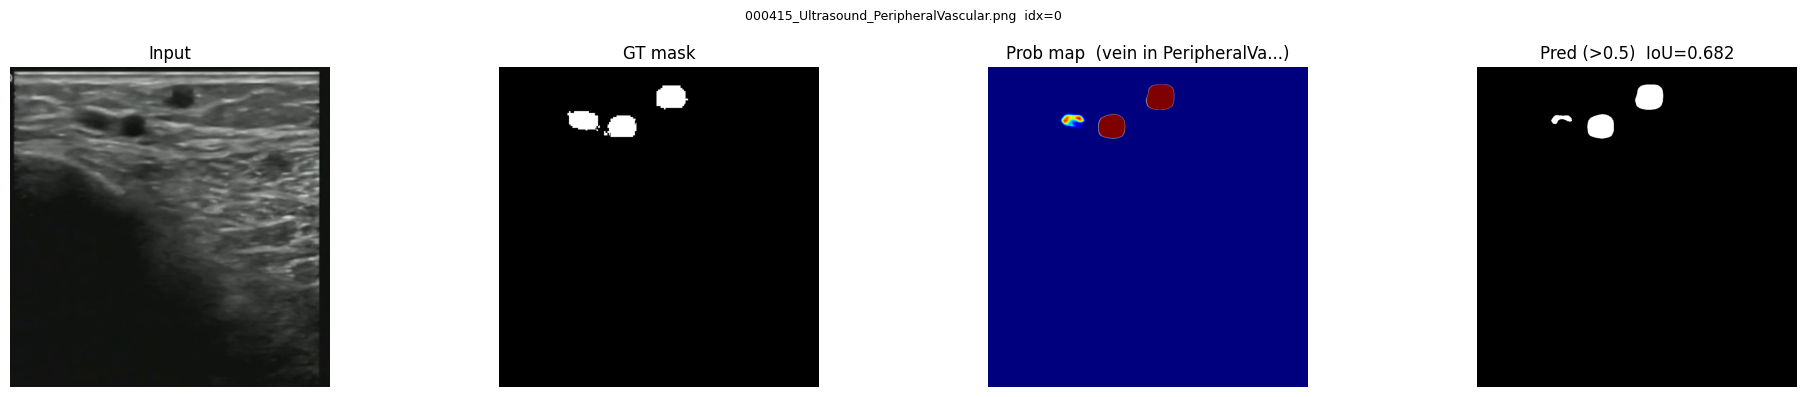

In [67]:
idx          = 0
use_vein_ann = True   # False = pick from fascia test annotations

ann_list = vein_test_anns if use_vein_ann else [a for a in test_coco['annotations'] if a['category_id'] == FASCIA_CAT_ID]
ann      = ann_list[idx]

pil_img  = Image.open(TEST_IMG_DIR  / ann['file_name']).convert('RGB')
H, W     = pil_img.size[1], pil_img.size[0]
gt_raw   = np.array(Image.open(TEST_MASK_DIR / ann['mask_file']).convert('L'))
gt_bin   = (gt_raw > 0).astype(np.uint8) if gt_raw.max() <= 1 else (gt_raw > 127).astype(np.uint8)

prompt   = VEIN_PROMPT if use_vein_ann else FASCIA_PROMPT
outputs, _ = infer_grounding(pil_img, prompt)
prob       = grounding_to_prob(outputs, H, W)
pred_bin   = (prob > 0.5).astype(np.uint8)

inter = int((pred_bin & gt_bin).sum())
union = int((pred_bin | gt_bin).sum())
iou   = inter / (union + 1e-6)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(pil_img);                               axes[0].set_title('Input')
axes[1].imshow(gt_bin,   cmap='gray');                 axes[1].set_title('GT mask')
axes[2].imshow(prob,     cmap='jet', vmin=0, vmax=1); axes[2].set_title(f'Prob map  ({prompt[:20]}...)')
axes[3].imshow(pred_bin, cmap='gray');                 axes[3].set_title(f'Pred (>0.5)  IoU={iou:.3f}')
for ax in axes: ax.axis('off')
plt.suptitle(f'{ann["file_name"]}  idx={idx}', fontsize=9)
plt.tight_layout()
plt.show()